In [1]:
!pip install -q datasets sentence-transformers faiss-cpu transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 63.9 MB/s eta 0:00:00:00:0100:01


In [2]:
import numpy as np
import pandas as pd
import re
import faiss
import pickle
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [3]:
dataset = load_dataset("pubmed_qa", "pqa_unlabeled")

def build_corpus(example):
    text = " ".join(example["context"]["contexts"])
    return {"text": text}

dataset = dataset.map(build_corpus)

corpus = dataset["train"]["text"]

README.md: 0.00B [00:00, ?B/s]

pqa_unlabeled/train-00000-of-00001.parqu(…):   0%|          | 0.00/66.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61249 [00:00<?, ? examples/s]

Map:   0%|          | 0/61249 [00:00<?, ? examples/s]

In [4]:
def clean_text(t):
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

corpus = [clean_text(t) for t in corpus]

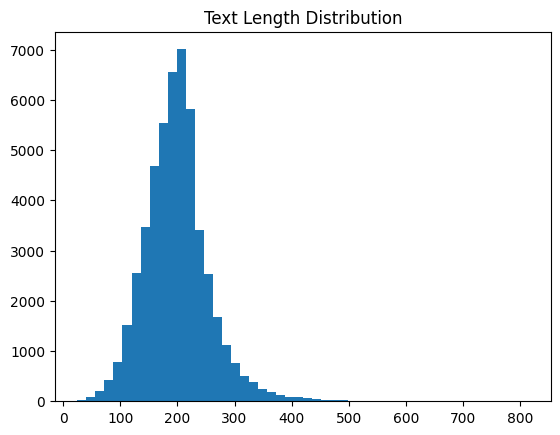

Avg: 198.92342
Max: 814

Sample:
 although the use of alternative medicine in the united states is increasing, no published studies have documented the effectiveness of naturopathy for treatment of menopausal symptoms compared to women receiving conventional therapy in the clinical setting. to compare naturopathic therapy with conve

Sample:
 to estimate the feasibility, utility and resource implications of electronically captured routine data for health technology assessment by randomised controlled trials (rcts), and to recommend how routinely collected data could be made more effective for this purpose. four health technology assessme


In [5]:
corpus_subset = corpus[:50000]

lengths = [len(text.split()) for text in corpus_subset]

plt.hist(lengths, bins=50)
plt.title("Text Length Distribution")
plt.show()

print("Avg:", np.mean(lengths))
print("Max:", np.max(lengths))

for i in range(2):
    print("\nSample:\n", corpus_subset[i][:300])

In [6]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(
    corpus_subset,
    batch_size=64,
    show_progress_bar=True
)

embeddings = np.array(embeddings).astype("float32")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/782 [00:00<?, ?it/s]

In [7]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print("Vectors:", index.ntotal)

Vectors: 50000


In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Clustering with K-Means
num_clusters = 5  # You can adjust this based on the variance
kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

# 2. Evaluation with Silhouette Score
# Note: Silhouette score can be slow on large datasets; using a sample of 10k for speed
sample_idx = np.random.choice(len(embeddings), 10000, replace=False)
score = silhouette_score(embeddings[sample_idx], cluster_labels[sample_idx])

print(f"Clusters Assigned: {np.unique(cluster_labels)}")
print(f"Silhouette Score (Unsupervised Proof): {score:.4f}")

Clusters Assigned: [0 1 2 3 4]
Silhouette Score (Unsupervised Proof): 0.0360


In [8]:
def search(query, k=3):
    query_vec = embedding_model.encode([query]).astype("float32")
    
    distances, indices = index.search(query_vec, k)
    
    results = []
    for i in range(k):
        idx = indices[0][i]
        results.append({
            "text": corpus_subset[idx],
            "score": float(distances[0][i])
        })
    
    return results

In [9]:
model_name = "google/flan-t5-large"

tokenizer = AutoTokenizer.from_pretrained(model_name)
generation_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
generation_model = generation_model.to(device)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [10]:
def generate_answer(query, text):
    # We add "Explain in 2 sentences" to guide the output length
    # Update the prompt inside generate_answer to be more 'ASHA-friendly'
    prompt = (
        f"Context: {text}\n\n"
        f"Task: You are a senior doctor. Explain the answer to a rural health worker using simple language.\n"
        f"Question: {query}\n"
        f"Simple Explanation:"
    )
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(device)
    
    outputs = generation_model.generate(
        **inputs, 
        max_new_tokens=150, 
        num_beams=5, 
        no_repeat_ngram_size=3,
        repetition_penalty=1.5,
        length_penalty=1.2 # Encourages slightly longer, more descriptive sentences
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [11]:
def generate_final_answer(query):
    results = search(query, k=3)
    best_similarity = 1 / (1 + results[0]['score'])
    
    # Check if we have a strong match in the dataset
    if best_similarity >= 0.45:
        combined_text = " ".join([r["text"] for r in results])[:1500]
        answer = generate_answer(query, combined_text)
        source = "Official Health Manual"
    else:
        # Fallback to model's own knowledge if dataset match is weak
        prompt = f"Question: {query}\n\nProvide general health information and advice as a medical assistant. Always suggest consulting a doctor for persistent symptoms."
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        outputs = generation_model.generate(**inputs, max_new_tokens=200, do_sample=True, temperature=0.7)
        answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
        source = "General AI Knowledge (Not in Manual)"
    
    
    return f"[{source}]\n{answer}\n\n*DISCLAIMER: This is an AI assistant. Always consult a doctor before starting medication.*", results

In [12]:
query = "What are the long-term effects of occupational back injuries?"

answer, results = generate_final_answer(query)

print("🔎 Query:", query)
print("\n🧠 Answer:\n", answer)

print("\n📚 Evidence:\n")

for i, res in enumerate(results):
    sim = 1 / (1 + res['score'])
    print(f"\nResult {i+1} (Similarity: {sim:.4f})")
    print(res["text"][:])

🔎 Query: What are the long-term effects of occupational back injuries?

🧠 Answer:
 [Official Health Manual]
An estimated $8.8 billion was spent on low back pain claim costs during this time (58%). in 1995, however occupational Low Back Pain remains a major problem In the United States: an Estimated $ 8. 8 BILLION WAS SPENT ON LBP CLAIM CLAIMS AND THE RATE OF FILMING LIFE OR DEATH INJURY REQUESTIONS WERE 1,815,894

*DISCLAIMER: This is an AI assistant. Always consult a doctor before starting medication.*

📚 Evidence:


Result 1 (Similarity: 0.5714)
a retrospective analysis of back pain claim data from two sources, a workers' compensation provider and washington state department of labor and industries. the workers' compensation provider claim data were examined over a 9-year period, 1987-1995, and the washington claim data were examined over a 5-year period, 1991-1995. in addition, a third source of data, reports of back pain from the the bureau of labor statistics, was examined over a 

In [13]:
queries = [
    "fever treatment",
    "body pain remedies",
    "infection symptoms"
]

for q in queries:
    print("\n" + "="*60)
    print("Query:", q)
    ans, _ = generate_final_answer(q)
    print("Answer:", ans)


Query: fever treatment
Answer: [Official Health Manual]
Fever is a common clinical practice in intensive care, although it's known that fever may be harmful or beneficial of infection and inflammation. Eighteen patients receiving external cooling while 20 received no antipyretic treatment were evaluated for rectal temperature (temperaturation>/=38.5 degrees C) with systemic Inflammatory Response Syndrome(SIRSS). Temperaturor discomfort decreased similarlyin both groups after 24 hours without any significant differences found between the two group during this time period

*DISCLAIMER: This is an AI assistant. Always consult a doctor before starting medication.*

Query: body pain remedies
Answer: [Official Health Manual]
Musculoskeletal pain can be treated with physical exercise, massage and acupuncture. Massage is used to relax the muscles in your lower back that are responsible for keeping you from moving around too much while standing or sitting down when doing activities of daily li

In [14]:
# FAISS
faiss.write_index(index, "faiss_index.bin")

# corpus
with open("corpus.pkl", "wb") as f:
    pickle.dump(corpus_subset, f)

# embedding model
embedding_model.save("embedding_model")

# generation model
generation_model.save_pretrained("generation_model")
tokenizer.save_pretrained("generation_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('generation_model/tokenizer_config.json', 'generation_model/tokenizer.json')

In [ ]:
import os
import zipfile

# Define exactly what you want to download
files_to_zip = [
    'faiss_index.bin',
    'corpus.pkl',
    'generation_model/', # The folder where you saved the model
    'embedding_model/'
]

zip_name = 'medassist_outputs.zip'

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for item in files_to_zip:
        if os.path.isfile(item):
            zipf.write(item)
        elif os.path.isdir(item):
            for root, dirs, files in os.walk(item):
                for file in files:
                    zipf.write(os.path.join(root, file))

print(f"Created {zip_name} successfully!")

In [16]:
# from IPython.display import FileLink
# # This creates a clickable link inside your notebook cell
# FileLink(r'medassist_project_files.zip')